## Activity: Build a decision tree

For this activity, you work as a consultant for an airline. The airline is interested in predicting whether a future customer would be satisfied with their services given previous customer feedback about their flight experience.

In [57]:
# Main Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [58]:
# Load the data set

airline_raw = pd.read_csv('./raw_data/Invistico_Airline.csv')
airline_raw.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [59]:
# Check null values

airline_raw.isna().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [60]:
# Now check the balance distribution betwen classes for the desire model outcome

print(airline_raw.groupby(by=['satisfaction'])['satisfaction'].value_counts())
print("==="*10)
print(f'DataFrame Shape: {airline_raw.shape}')

satisfaction
dissatisfied    58793
satisfied       71087
Name: count, dtype: int64
DataFrame Shape: (129880, 22)


In [61]:
airline_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [62]:
print(np.unique(airline_raw['Class']))
print(np.unique(airline_raw['Type of Travel']))
print(np.unique(airline_raw['Customer Type']))

['Business' 'Eco' 'Eco Plus']
['Business travel' 'Personal Travel']
['Loyal Customer' 'disloyal Customer']


In [63]:
# remove the nulls from the Arrival Delay in Minutes column

airline_info = airline_raw.dropna(axis=0)
print(f"Dataframe dimension after removing NAs: {airline_info.shape}")
print("==="*10)
airline_info.head()

Dataframe dimension after removing NAs: (129487, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


#### Data Transformation / Feauture Transfomation

In [64]:
# Convert those Categorical Varibales into binary 0 / 1 values

airline_info['satisfaction'] = airline_info['satisfaction'].map({'satisfied':1,'dissatisfied':0})
airline_info['Class'] = airline_info['Class'].map({'Business': 0,'Eco':1 ,'Eco Plus':2})
airline_info['Type of Travel'] = airline_info['Type of Travel'].map({'Business travel': 0,'Personal Travel':1})

C:\Users\andre\AppData\Local\Temp\ipykernel_15548\2936986426.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airline_info['satisfaction'] = airline_info['satisfaction'].map({'satisfied':1,'dissatisfied':0})
C:\Users\andre\AppData\Local\Temp\ipykernel_15548\2936986426.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airline_info['Class'] = airline_info['Class'].map({'Business': 0,'Eco':1 ,'Eco Plus':2})
C:\Users\andre\AppData\Local\Temp\ipykernel_15548\2936986426.py:5: SettingWithCopyWarning: 
A value

In [65]:
# Another way to transform categorical data is by using the 
# getdummies method

airline_info = pd.get_dummies(airline_info,drop_first=True,dtype=int)
airline_info.dtypes

satisfaction                           int64
Age                                    int64
Type of Travel                         int64
Class                                  int64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_disloyal Customer        int64
dtype: obj

In [66]:
airline_info.head(10)

,satisfaction,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer
0,1,65,1,1,265,0,0,0,2,2,...,3,3,0,3,5,3,2,0,0.0,0
1,1,47,1,0,2464,0,0,0,3,0,...,3,4,4,4,2,3,2,310,305.0,0
2,1,15,1,1,2138,0,0,0,3,2,...,2,3,3,4,4,4,2,0,0.0,0
3,1,60,1,1,623,0,0,0,3,3,...,1,1,0,1,4,1,3,0,0.0,0
4,1,70,1,1,354,0,0,0,3,4,...,2,2,0,2,4,2,5,0,0.0,0
5,1,30,1,1,1894,0,0,0,3,2,...,2,5,4,5,5,4,2,0,0.0,0
6,1,66,1,1,227,0,0,0,3,2,...,5,5,0,5,5,5,3,17,15.0,0
7,1,10,1,1,1812,0,0,0,3,2,...,2,3,3,4,5,4,2,0,0.0,0
8,1,56,1,0,73,0,0,0,3,5,...,4,4,0,1,5,4,4,0,0.0,0
9,1,22,1,1,1556,0,0,0,3,2,...,2,2,4,5,3,4,2,30,26.0,0


In [67]:
y = airline_info['satisfaction']

columns = airline_info.columns
print(columns[1:])

x = airline_info[columns[1:]]
x.head(10)

Index(['Age', 'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'Customer Type_disloyal Customer'],
      dtype='object')


,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,...,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer
0,65,1,1,265,0,0,0,2,2,4,...,3,3,0,3,5,3,2,0,0.0,0
1,47,1,0,2464,0,0,0,3,0,2,...,3,4,4,4,2,3,2,310,305.0,0
2,15,1,1,2138,0,0,0,3,2,0,...,2,3,3,4,4,4,2,0,0.0,0
3,60,1,1,623,0,0,0,3,3,4,...,1,1,0,1,4,1,3,0,0.0,0
4,70,1,1,354,0,0,0,3,4,3,...,2,2,0,2,4,2,5,0,0.0,0
5,30,1,1,1894,0,0,0,3,2,0,...,2,5,4,5,5,4,2,0,0.0,0
6,66,1,1,227,0,0,0,3,2,5,...,5,5,0,5,5,5,3,17,15.0,0
7,10,1,1,1812,0,0,0,3,2,0,...,2,3,3,4,5,4,2,0,0.0,0
8,56,1,0,73,0,0,0,3,5,3,...,4,4,0,1,5,4,4,0,0.0,0
9,22,1,1,1556,0,0,0,3,2,0,...,2,2,4,5,3,4,2,30,26.0,0


In [68]:
# Split the data into test and train
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

### Build the Model

In [69]:
decisionTreeModel = DecisionTreeClassifier(random_state=0).fit(x_train,y_train)

model_predictions = decisionTreeModel.predict(x_test)

In [70]:
# Creck how does the model perform by Metrics

print("Decision Tree Model Perfomance by Metrics")
print(f"Accuracy Score: {accuracy_score(y_test,model_predictions):.4f}")
print(f"Precision Score: {precision_score(y_test,model_predictions):.4f}")
print(f"Recall Score: {recall_score(y_test,model_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test,model_predictions):.4f}")

Decision Tree Model Perfomance by Metrics
Accuracy Score: 0.9335
Precision Score: 0.9365
Recall Score: 0.9421
F1 Score: 0.9393


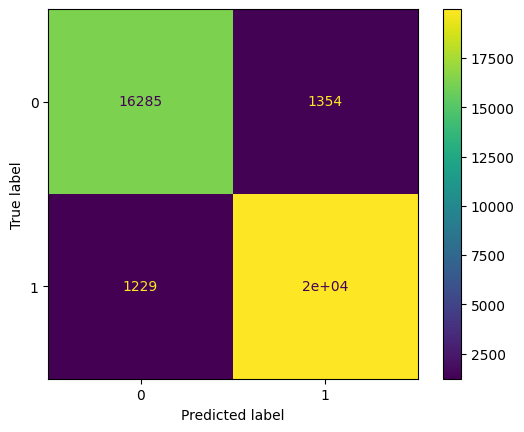

In [71]:
# Build the confusion matrix

confMtrx = confusion_matrix(y_test,model_predictions,labels=decisionTreeModel.classes_)
confMtrxDisp = ConfusionMatrixDisplay(confusion_matrix=confMtrx,display_labels=decisionTreeModel.classes_)

confMtrxDisp.plot()

[Text(0.5, 0.875, 'Inflight entertainment <= 3.5\ngini = 0.495\nsamples = 90640\nvalue = [40966, 49674]'),
 Text(0.25, 0.625, 'Seat comfort <= 3.5\ngini = 0.338\nsamples = 40488\nvalue = [31769, 8719]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Seat comfort <= 0.5\ngini = 0.248\nsamples = 35414\nvalue = [30288, 5126]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Seat comfort <= 4.5\ngini = 0.413\nsamples = 5074\nvalue = [1481.0, 3593.0]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Ease of Online booking <= 3.5\ngini = 0.3\nsamples = 50152\nvalue = [9197, 40955]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Inflight entertainment <= 4.5\ngini = 0.484\nsamples = 13697\nvalue = [5635.0, 8062.0]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Customer Type_disloyal Customer <= 0.5\ngini = 0.176\nsamples = 36

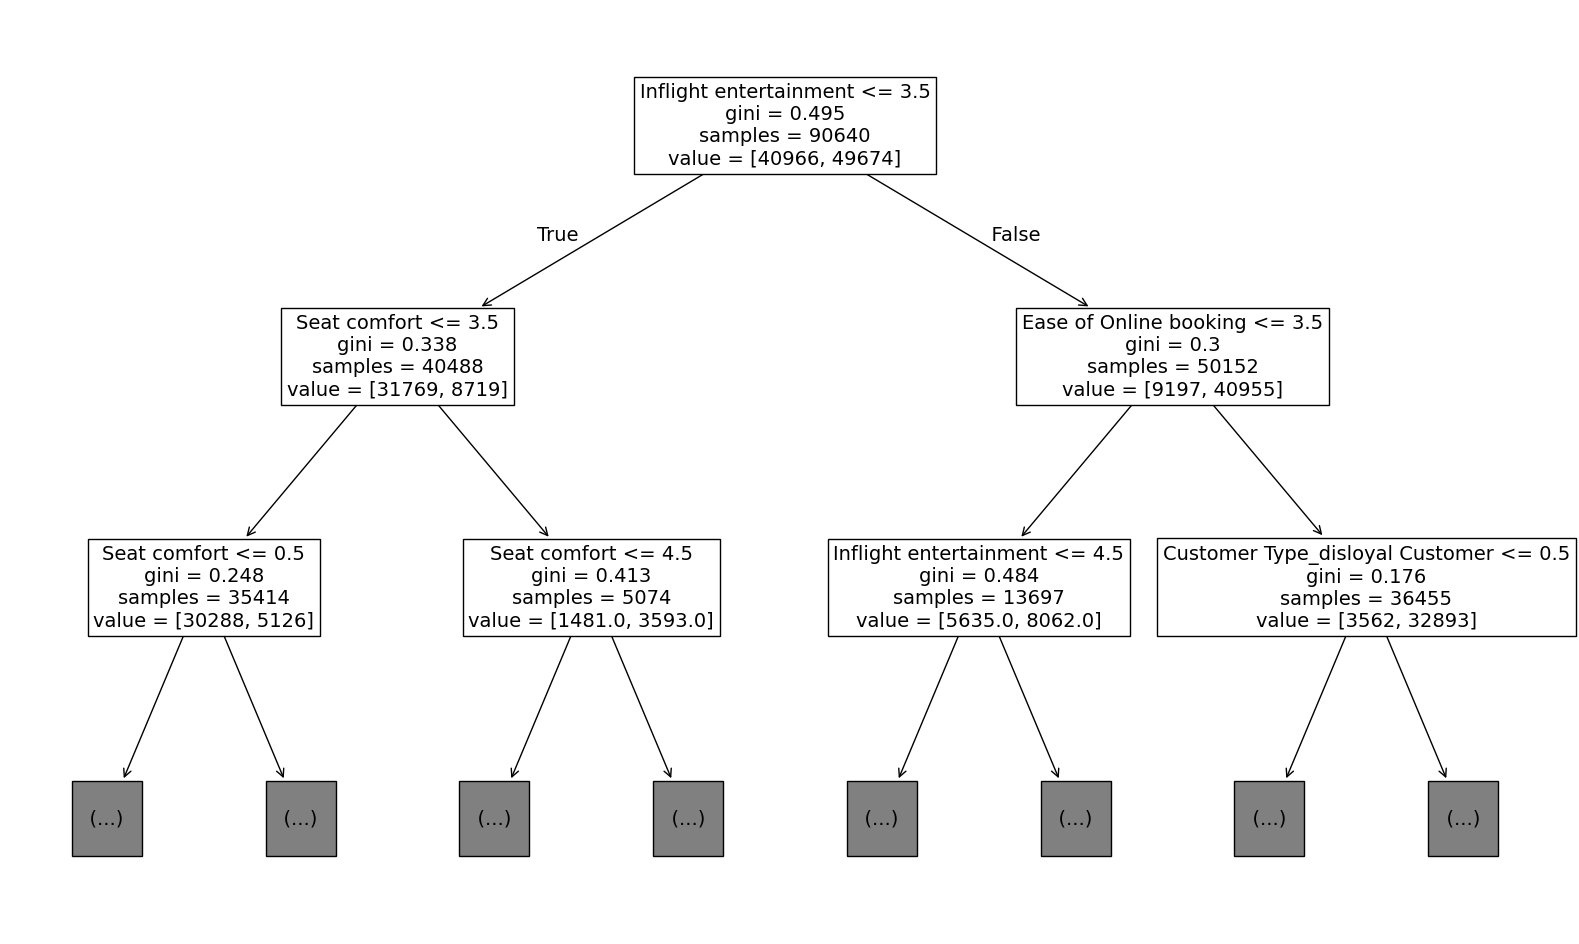

In [72]:
# Check how the three is been builided

plt.figure(figsize=(20,12))
plot_tree(decisionTreeModel,max_depth=2,fontsize=14, feature_names=x.columns)

### Calculate Feature importance

For each feature used in the tree, the algorithm finds all of the decision nodes that use that particular feature as the split criterion. Then for each of those decision nodes it computes the decrease in Gini impurity (or entropy, or log loss, or whatever metric you select when you fit the model—default is Gini impurity) that results from that split (so, the decrease from parent to children). Then the algorithm sums up the decreases across all the decisions made using that feature and expresses it as a percentage of the total decrease that resulted from all features.

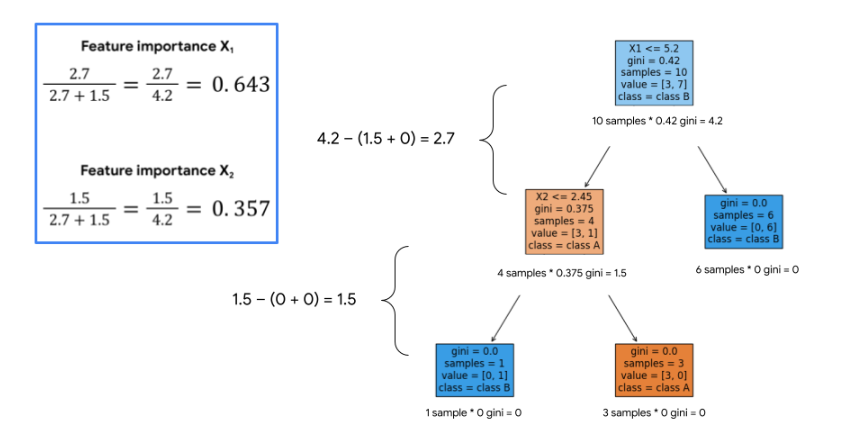

In [73]:
# Calculate feature importance

featImportance = decisionTreeModel.feature_importances_
forestImportance = pd.Series(featImportance,index=x.columns).sort_values(ascending=False)

forestImportance = pd.DataFrame(forestImportance)
forestImportance.rename(columns={0:'Feaure_importance'},inplace=True)

## Hyperparameter Tuning

In [74]:
hyperpara_setup = {
    'max_depth':[2,3,4,5,10,20,30,50,100,200],
    'min_samples_leaf':[5,10,12,14,16,18,20,50,75,100]
}

decisionTreeTuning = DecisionTreeClassifier(random_state=0)

tuned_model = GridSearchCV(
    decisionTreeTuning,
    hyperpara_setup,
    scoring='f1',
    cv=5,
    refit='f1'
)

tuned_model.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [75]:
print(tuned_model.best_estimator_)
print(tuned_model.best_score_)

DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, random_state=0)
0.9410994539745134


In [76]:
scores_list = ['recall','accuracy','precision','f1']

for score in scores_list:
    tuned_model = GridSearchCV(
        decisionTreeTuning,
        hyperpara_setup,
        scoring=score,
        cv=5,
        refit='f1'
    )

    tuned_model.fit(x_train,y_train)

    print("===="*10)
    print(f"Best model based on {score}")
    print(f"The best Estimator for the model is: {tuned_model.best_estimator_}")
    print(f"The best score for that estimator was: {tuned_model.best_score_:.4f}")
    print("===="*10)
    

Best model based on recall
The best Estimator for the model is: DecisionTreeClassifier(max_depth=50, min_samples_leaf=5, random_state=0)
The best score for that estimator was: 0.9370
Best model based on accuracy
The best Estimator for the model is: DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, random_state=0)
The best score for that estimator was: 0.9358
Best model based on precision
The best Estimator for the model is: DecisionTreeClassifier(max_depth=20, min_samples_leaf=10, random_state=0)
The best score for that estimator was: 0.9476
Best model based on f1
The best Estimator for the model is: DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, random_state=0)
The best score for that estimator was: 0.9411


[Text(0.5, 0.875, 'Inflight entertainment <= 3.5\ngini = 0.495\nsamples = 90640\nvalue = [40966, 49674]'),
 Text(0.25, 0.625, 'Seat comfort <= 3.5\ngini = 0.338\nsamples = 40488\nvalue = [31769, 8719]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Seat comfort <= 0.5\ngini = 0.248\nsamples = 35414\nvalue = [30288, 5126]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Seat comfort <= 4.5\ngini = 0.413\nsamples = 5074\nvalue = [1481.0, 3593.0]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Ease of Online booking <= 3.5\ngini = 0.3\nsamples = 50152\nvalue = [9197, 40955]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Inflight entertainment <= 4.5\ngini = 0.484\nsamples = 13697\nvalue = [5635.0, 8062.0]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Customer Type_disloyal Customer <= 0.5\ngini = 0.176\nsamples = 36

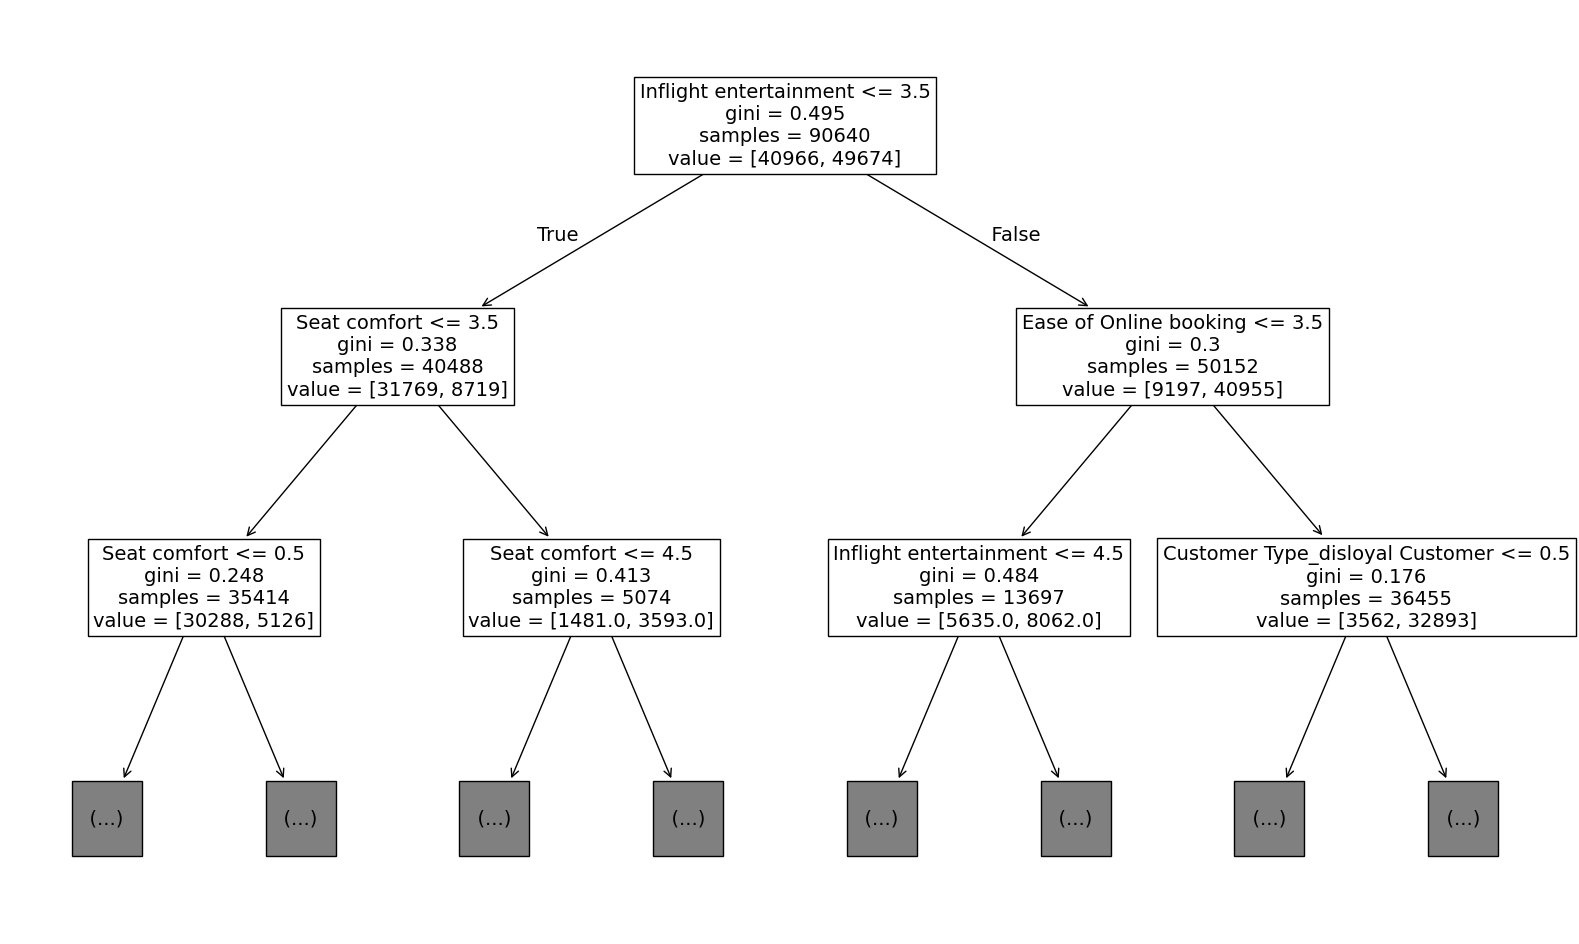

In [77]:
plt.figure(figsize=(20,12))
plot_tree(
    tuned_model.best_estimator_,
    max_depth=2,
    fontsize=14,
    feature_names=x.columns
)

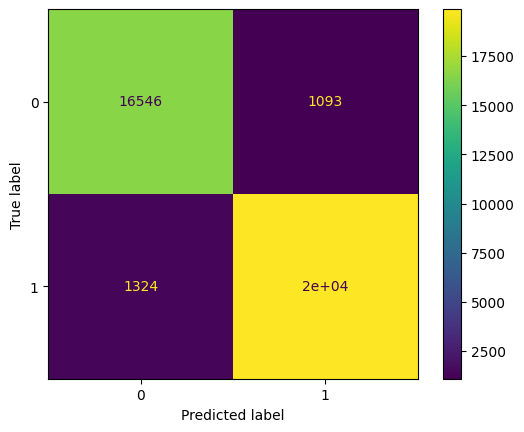

In [78]:
bestModelDT = tuned_model.best_estimator_
bestPredictions = bestModelDT.predict(x_test)

confMtrxBM = confusion_matrix(y_test,bestPredictions,labels=bestModelDT.classes_)
confMtrxBMDisp = ConfusionMatrixDisplay(confusion_matrix=confMtrxBM,display_labels=bestModelDT.classes_)
confMtrxBMDisp.plot()

In [79]:
featureImportance = bestModelDT.feature_importances_

forestImportanceBM = pd.Series(featureImportance,index= x.columns)
forestImportanceBM = pd.DataFrame(forestImportanceBM)
forestImportanceBM.rename(columns={0:'Feat_importance_best_model'},inplace=True)

In [ ]:
forestImportanceComp = forestImportanceBM.join(forestImportance)
forestImportanceComp

,Feat_importance_best_model,Feaure_importance
Age,0.017477,0.026416
Type of Travel,0.023971,0.022780
Class,0.024426,0.023474
Flight Distance,0.018883,0.034700
Seat comfort,0.192898,0.177907
Departure/Arrival time convenient,0.020515,0.022399
Food and drink,0.013433,0.014615
Gate location,0.027695,0.029433
Inflight wifi service,0.005764,0.008204
Inflight entertainment,0.429706,0.392315


In [81]:
forestImportanceComp.sort_values(by='Feat_importance_best_model',ascending=False)

,Feat_importance_best_model,Feaure_importance
Inflight entertainment,0.429706,0.392315
Seat comfort,0.192898,0.177907
Ease of Online booking,0.070648,0.065469
Customer Type_disloyal Customer,0.044836,0.041565
Gate location,0.027695,0.029433
Class,0.024426,0.023474
Type of Travel,0.023971,0.022780
Departure/Arrival time convenient,0.020515,0.022399
Flight Distance,0.018883,0.034700
Online support,0.018056,0.020030
